# ❤️ Heart Disease Prediction
### AI/ML Engineering Internship — Task 3 | DevelopersHub Corporation

**Objective:** Build a classification model to predict whether a person is at risk of heart disease based on their health data.

**Dataset:** Heart Disease UCI Dataset (Cleveland)  
**Target Column:** `num` (0 = No Disease, 1+ = Heart Disease → converted to binary)  
**Models Used:** Logistic Regression, Decision Tree  
**Evaluation:** Accuracy, ROC-AUC, Confusion Matrix, Feature Importance

---

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📂 Step 2: Load the Dataset

In [2]:
# Load dataset — update filename if needed
df = pd.read_csv('heart_disease_uci.csv')

print(f'Dataset shape  : {df.shape}')
print(f'Rows           : {df.shape[0]}')
print(f'Columns        : {df.shape[1]}')
print(f'Column names   : {list(df.columns)}')
df.head()

Dataset shape  : (920, 16)
Rows           : 920
Columns        : 16
Column names   : ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


---
## 🔍 Step 3: Data Inspection

In [3]:
print('=== Data Types and Non-Null Counts ===')
df.info()

=== Data Types and Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
print('=== Descriptive Statistics ===')
df.describe(include='all').round(2)

=== Descriptive Statistics ===


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.00,920.00,920,920,920,861.00,890.00,830,918,865.00,865,858.00,611,309.00,434,920.00
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.50,53.51,NaN,NaN,NaN,132.13,199.13,NaN,NaN,137.55,NaN,0.88,NaN,0.68,NaN,1.00
std,265.73,9.42,NaN,NaN,NaN,19.07,110.78,NaN,NaN,25.93,NaN,1.09,NaN,0.94,NaN,1.14
min,1.00,28.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,60.00,NaN,-2.60,NaN,0.00,NaN,0.00
25%,230.75,47.00,NaN,NaN,NaN,120.00,175.00,NaN,NaN,120.00,NaN,0.00,NaN,0.00,NaN,0.00
50%,460.50,54.00,NaN,NaN,NaN,130.00,223.00,NaN,NaN,140.00,NaN,0.50,NaN,0.00,NaN,1.00
75%,690.25,60.00,NaN,NaN,NaN,140.00,268.00,NaN,NaN,157.00,NaN,1.50,NaN,1.00,NaN,2.00


In [5]:
# Check missing values
print('=== Missing Values Per Column ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
has_missing = missing_df[missing_df['Missing Count'] > 0]
print(has_missing if len(has_missing) > 0 else 'No missing values found!')

=== Missing Values Per Column ===
          Missing Count  Missing %
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2       0.22
thalch               55       5.98
exang                55       5.98
oldpeak              62       6.74
slope               309      33.59
ca                  611      66.41
thal                486      52.83


In [6]:
# Unique values in categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('=== Unique Values in Categorical Columns ===')
for col in cat_cols:
    print(f'  {col:12s} -> {df[col].unique().tolist()}')

=== Unique Values in Categorical Columns ===
  sex          -> ['Male', 'Female']
  dataset      -> ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
  cp           -> ['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
  fbs          -> [True, False, nan]
  restecg      -> ['lv hypertrophy', 'normal', 'st-t abnormality', nan]
  exang        -> [False, True, nan]
  slope        -> ['downsloping', 'flat', 'upsloping', nan]
  thal         -> ['fixed defect', 'normal', 'reversable defect', nan]


In [7]:
# Target column (num) raw distribution
print('=== Target Column (num) - Original Values ===')
print(df['num'].value_counts().sort_index())
print('\n  0 = No heart disease')
print('  1, 2, 3, 4 = Varying severity of heart disease')

=== Target Column (num) - Original Values ===
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

  0 = No heart disease
  1, 2, 3, 4 = Varying severity of heart disease


---
## 🧹 Step 4: Data Cleaning and Preprocessing

This dataset has several preprocessing needs:
- Drop `id` (row index) and `dataset` (all Cleveland)
- Binarize `num`: 0 = no disease, 1+ = disease
- Encode `sex`: Male/Female → 1/0
- Encode `fbs`, `exang`: TRUE/FALSE → 1/0
- One-hot encode: `cp`, `restecg`, `thal`, `slope`

In [8]:
# 4.1 Drop unnecessary columns
cols_to_drop = [c for c in ['id', 'dataset'] if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'Dropped columns  : {cols_to_drop}')
print(f'Remaining columns: {list(df.columns)}')

Dropped columns  : ['id', 'dataset']
Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [9]:
# 4.2 Binarize target column
# num > 0 means heart disease present
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

print('Target column binarized:')
print(df['target'].value_counts())
print(f'\n  0 = No Heart Disease : {(df["target"]==0).sum()} samples')
print(f'  1 = Heart Disease    : {(df["target"]==1).sum()} samples')

Target column binarized:
target
1    509
0    411
Name: count, dtype: int64

  0 = No Heart Disease : 411 samples
  1 = Heart Disease    : 509 samples


In [10]:
# 4.3 Encode TRUE/FALSE columns
bool_cols = [c for c in ['fbs', 'exang'] if c in df.columns]
for col in bool_cols:
    # Handle both string and actual bool types
    df[col] = df[col].map(lambda x: 1 if str(x).strip().upper() == 'TRUE' else 0)
    print(f'  {col}: TRUE/FALSE -> 1/0  | unique: {df[col].unique()}')

  fbs: TRUE/FALSE -> 1/0  | unique: [1 0]
  exang: TRUE/FALSE -> 1/0  | unique: [0 1]


In [11]:
# 4.4 Encode sex column
if 'sex' in df.columns:
    df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
    print(f'sex encoded  | unique: {df["sex"].unique()}')

sex encoded  | unique: [1 0]


In [12]:
# 4.5 One-hot encode multi-category columns
multi_cat_cols = [c for c in ['cp', 'restecg', 'thal', 'slope'] if c in df.columns]
print(f'One-hot encoding: {multi_cat_cols}')

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=False)

# Convert any boolean columns from get_dummies to int
bool_dtype_cols = df.select_dtypes(include='bool').columns
df[bool_dtype_cols] = df[bool_dtype_cols].astype(int)

print(f'New shape after encoding: {df.shape}')
print(f'All columns: {list(df.columns)}')

One-hot encoding: ['cp', 'restecg', 'thal', 'slope']
New shape after encoding: (920, 23)
All columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'target', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect', 'slope_downsloping', 'slope_flat', 'slope_upsloping']


In [13]:
# 4.6 Handle any remaining missing values
remaining_missing = df.isnull().sum()
cols_with_na = remaining_missing[remaining_missing > 0]

if len(cols_with_na) > 0:
    print(f'Columns still with NaN:\n{cols_with_na}')
    for col in cols_with_na.index:
        df[col] = df[col].fillna(df[col].median())
    print('Filled missing values with column median')
else:
    print('No missing values remaining!')

print(f'Final cleaned dataset shape: {df.shape}')
df.head(3)

Columns still with NaN:
trestbps     59
chol         30
thalch       55
oldpeak      62
ca          611
dtype: int64
Filled missing values with column median
Final cleaned dataset shape: (920, 23)


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,thal_fixed defect,thal_normal,thal_reversable defect,slope_downsloping,slope_flat,slope_upsloping
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,...,1,1,0,0,1,0,0,1,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,1,...,0,1,0,0,0,1,0,0,1,0
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,...,0,1,0,0,0,0,1,0,1,0


---
## 📊 Step 5: Exploratory Data Analysis (EDA)

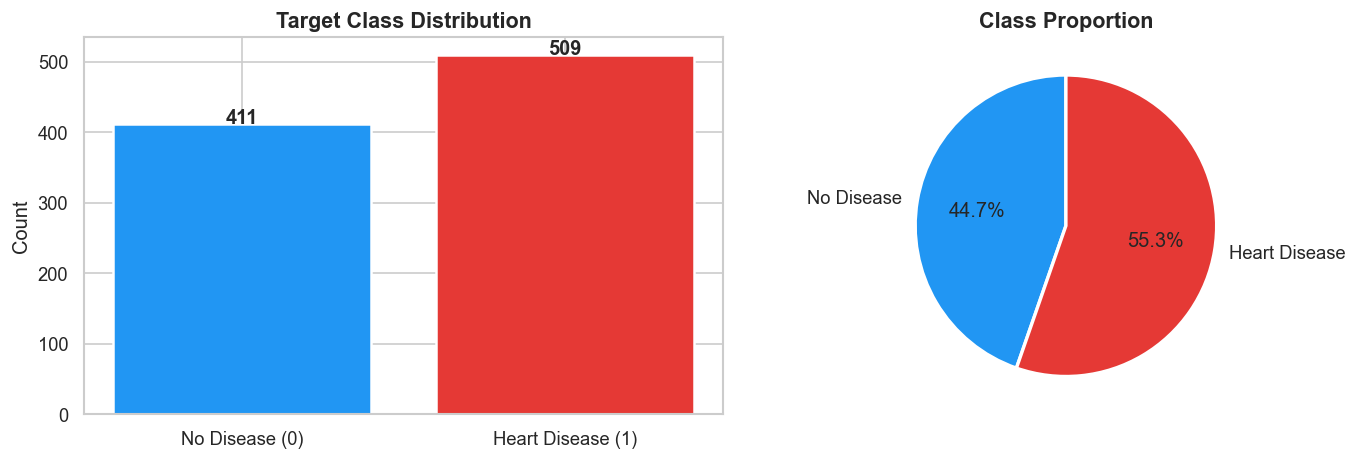

In [14]:
# 5.1 Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['target'].value_counts().sort_index()
colors = ['#2196F3', '#E53935']

axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
            color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', bbox_inches='tight')
plt.show()

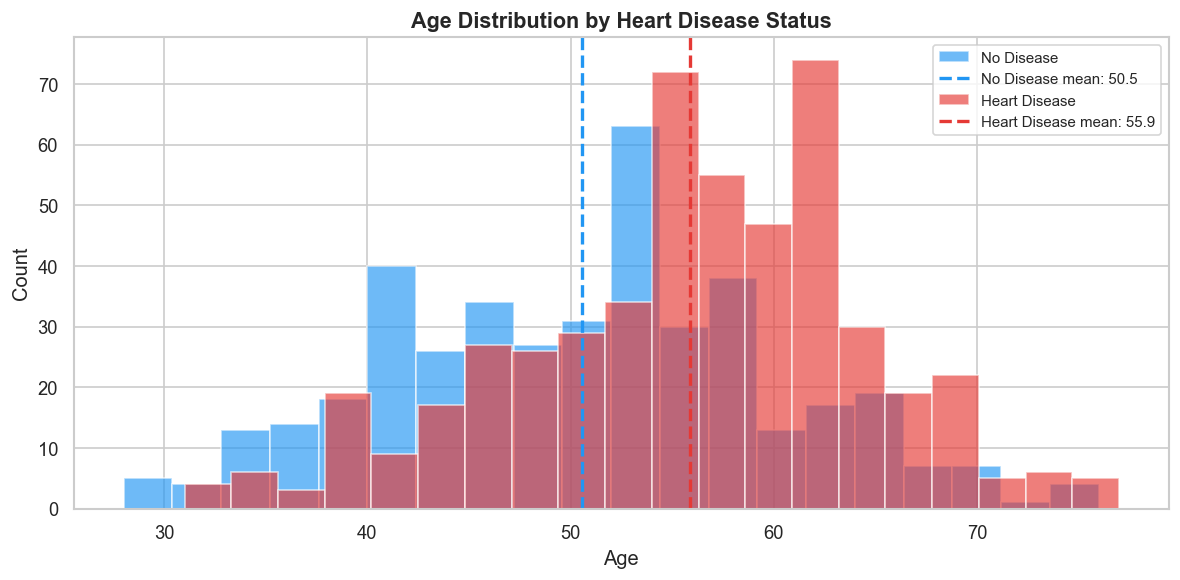

In [15]:
# 5.2 Age distribution by disease status
plt.figure(figsize=(10, 5))
for label, color, name in [(0, '#2196F3', 'No Disease'), (1, '#E53935', 'Heart Disease')]:
    subset = df[df['target'] == label]['age']
    plt.hist(subset, bins=20, alpha=0.65, color=color, label=name, edgecolor='white')
    plt.axvline(subset.mean(), color=color, linestyle='--', linewidth=2,
                label=f'{name} mean: {subset.mean():.1f}')

plt.title('Age Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('02_age_distribution.png', bbox_inches='tight')
plt.show()

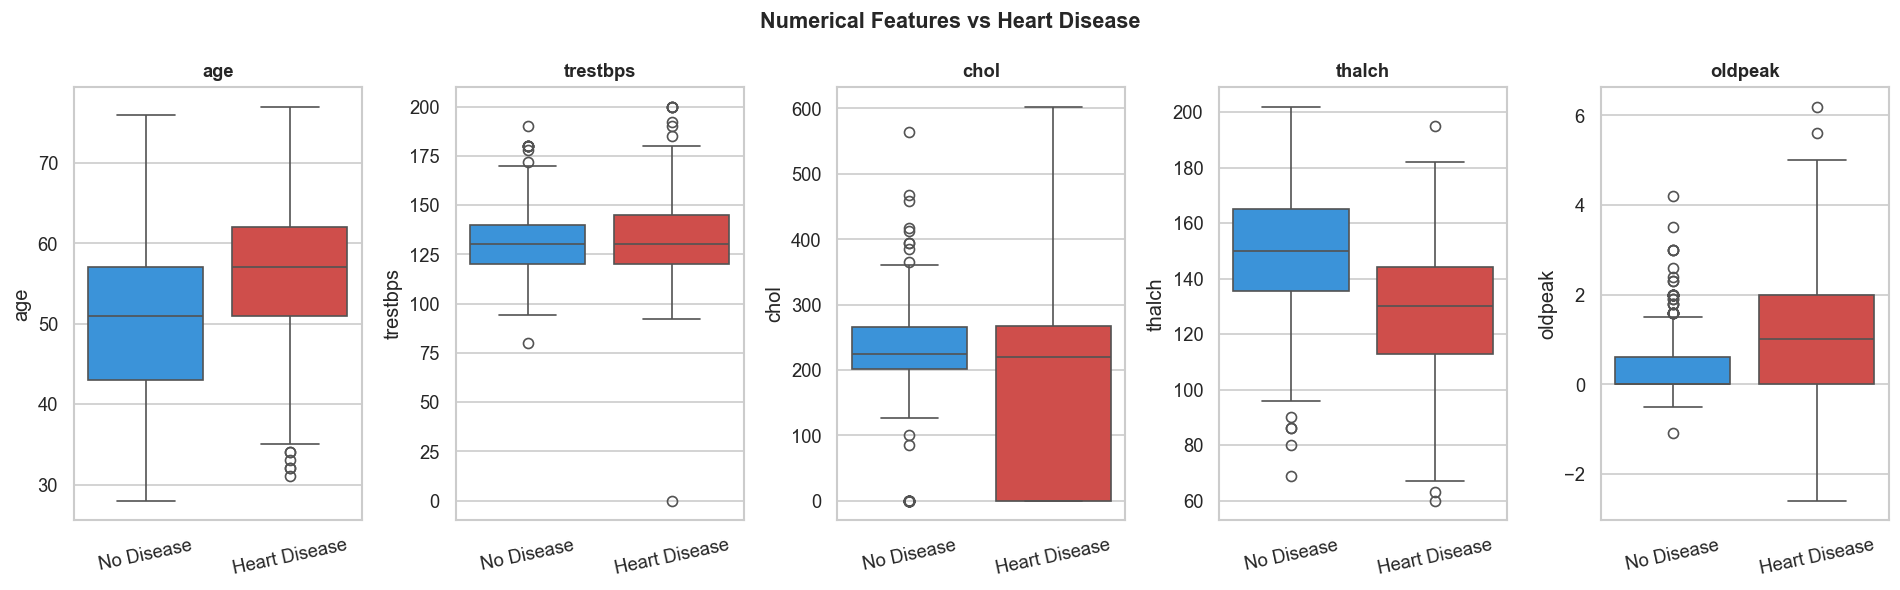

In [16]:
# 5.3 Key numerical features vs target (Box plots)
key_num_cols = [c for c in ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
                if c in df.columns]

fig, axes = plt.subplots(1, len(key_num_cols), figsize=(16, 5))
for ax, col in zip(axes, key_num_cols):
    plot_df = df[[col, 'target']].copy()
    plot_df['Status'] = plot_df['target'].map({0: 'No Disease', 1: 'Heart Disease'})
    sns.boxplot(x='Status', y=col, data=plot_df,
                palette={'No Disease': '#2196F3', 'Heart Disease': '#E53935'}, ax=ax)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=12)

plt.suptitle('Numerical Features vs Heart Disease', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_boxplots_vs_target.png', bbox_inches='tight')
plt.show()

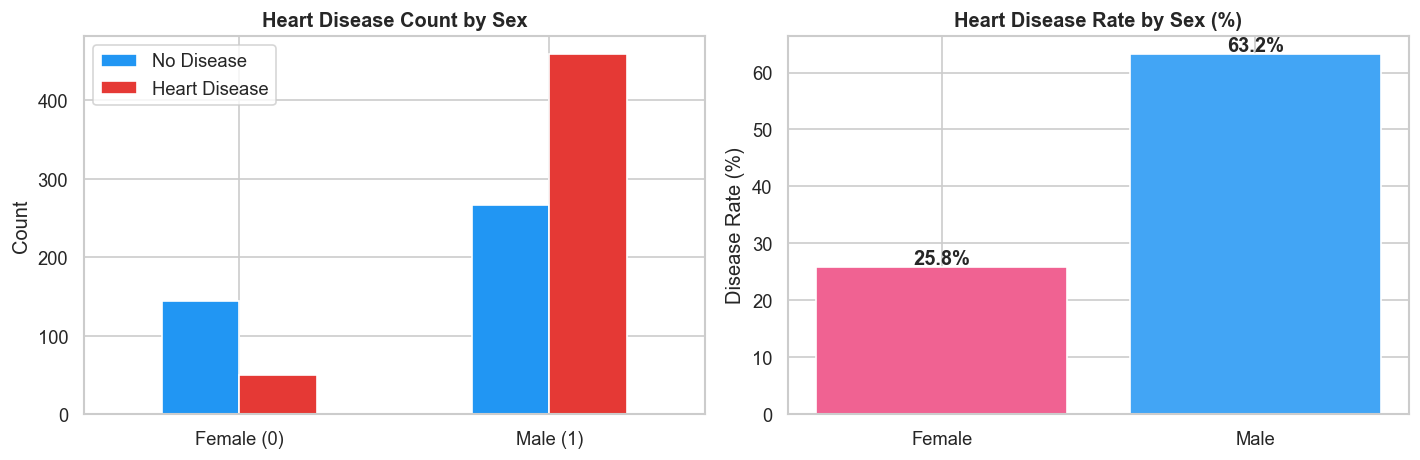

In [17]:
# 5.4 Sex vs Heart Disease
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex_target = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_target.index = ['Female (0)', 'Male (1)']
sex_target.columns = ['No Disease', 'Heart Disease']
sex_target.plot(kind='bar', ax=axes[0], color=['#2196F3', '#E53935'],
                edgecolor='white', rot=0)
axes[0].set_title('Heart Disease Count by Sex', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

sex_rate = df.groupby('sex')['target'].mean() * 100
sex_rate.index = ['Female', 'Male']
axes[1].bar(sex_rate.index, sex_rate.values, color=['#F06292', '#42A5F5'], edgecolor='white')
axes[1].set_title('Heart Disease Rate by Sex (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Disease Rate (%)')
for i, v in enumerate(sex_rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('04_sex_vs_disease.png', bbox_inches='tight')
plt.show()

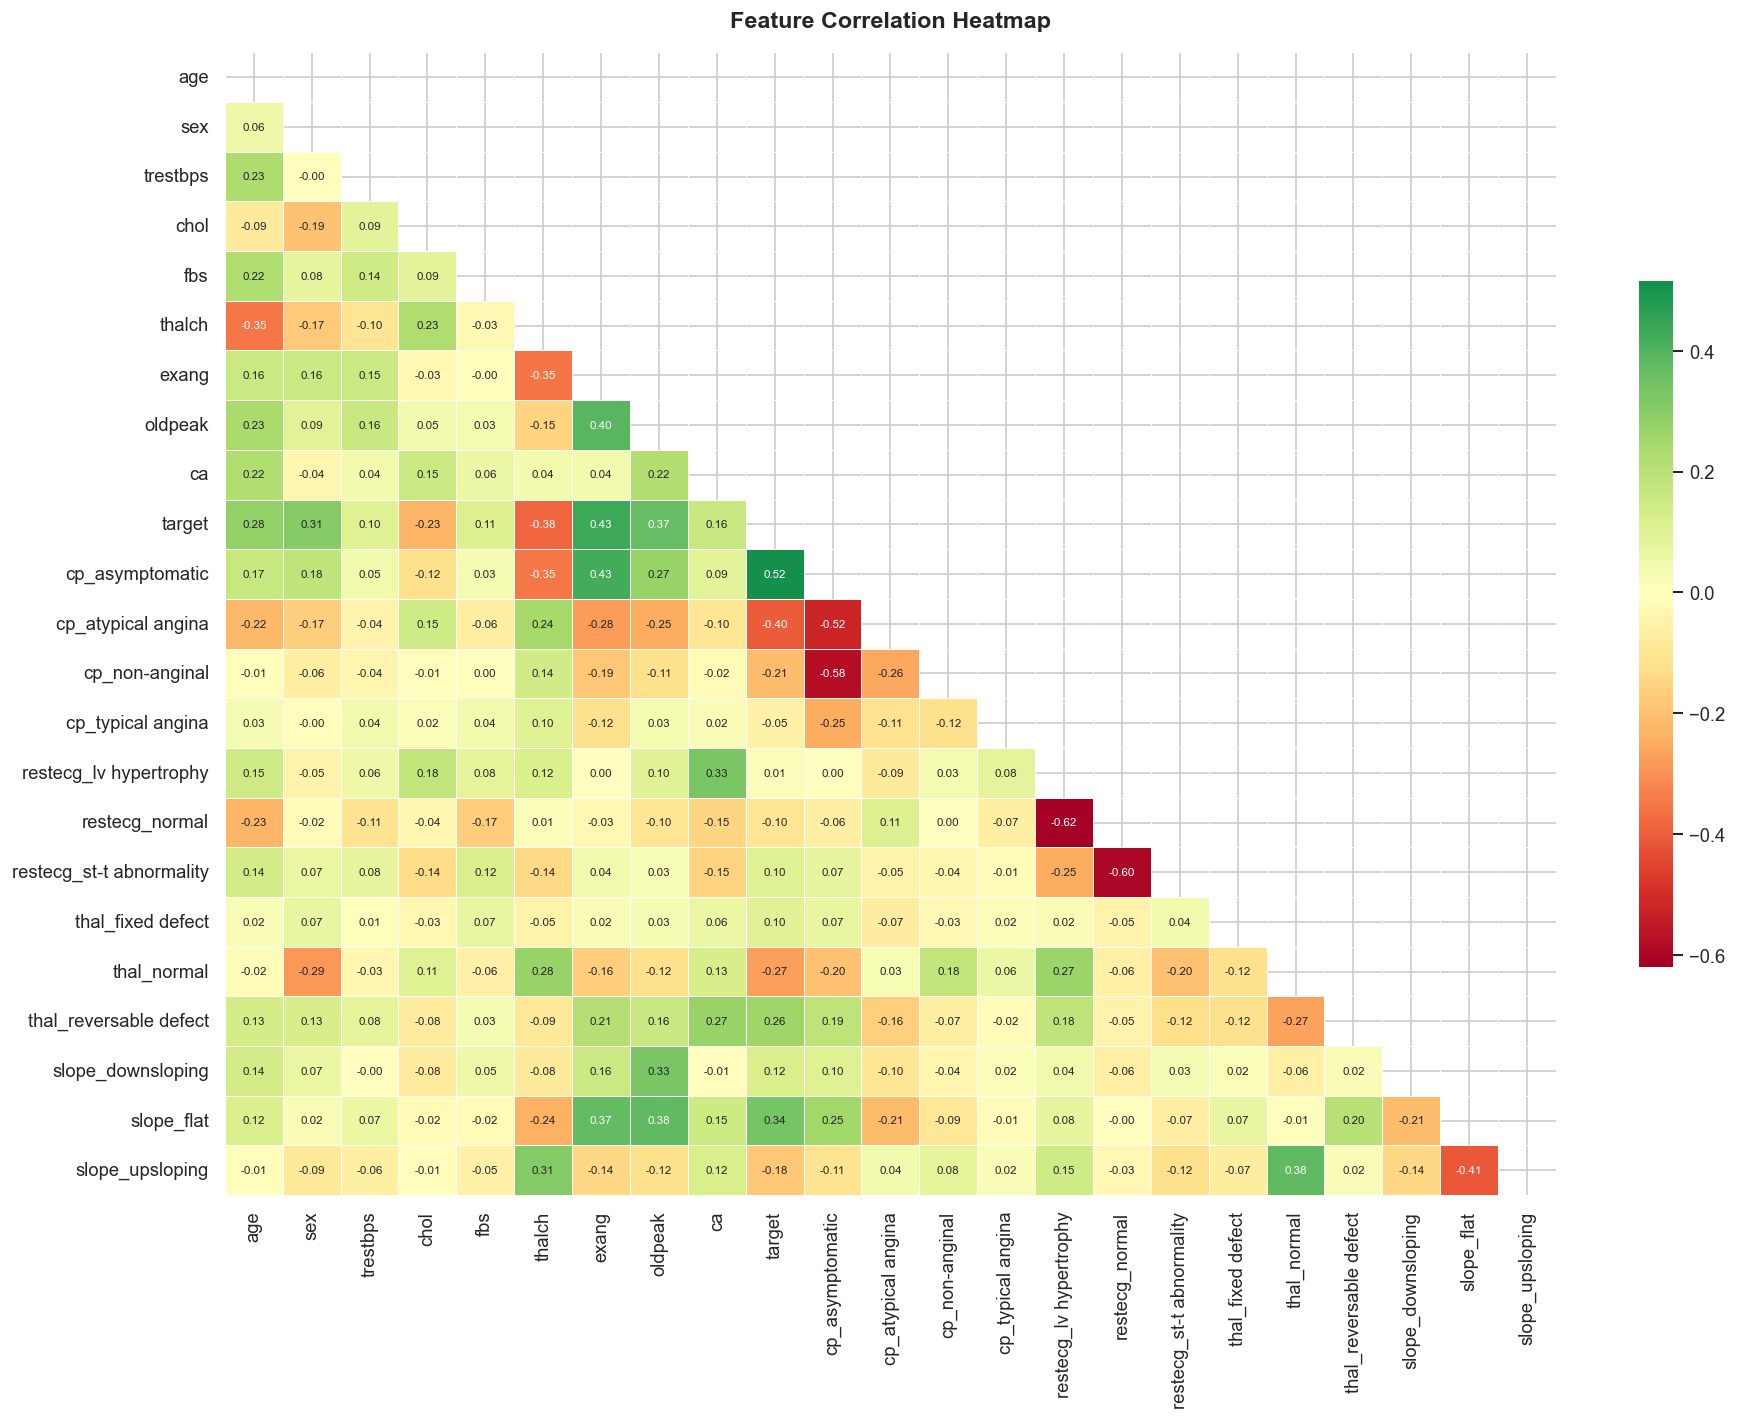

In [18]:
# 5.5 Correlation heatmap
num_only = df.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 12))
corr = num_only.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.6})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

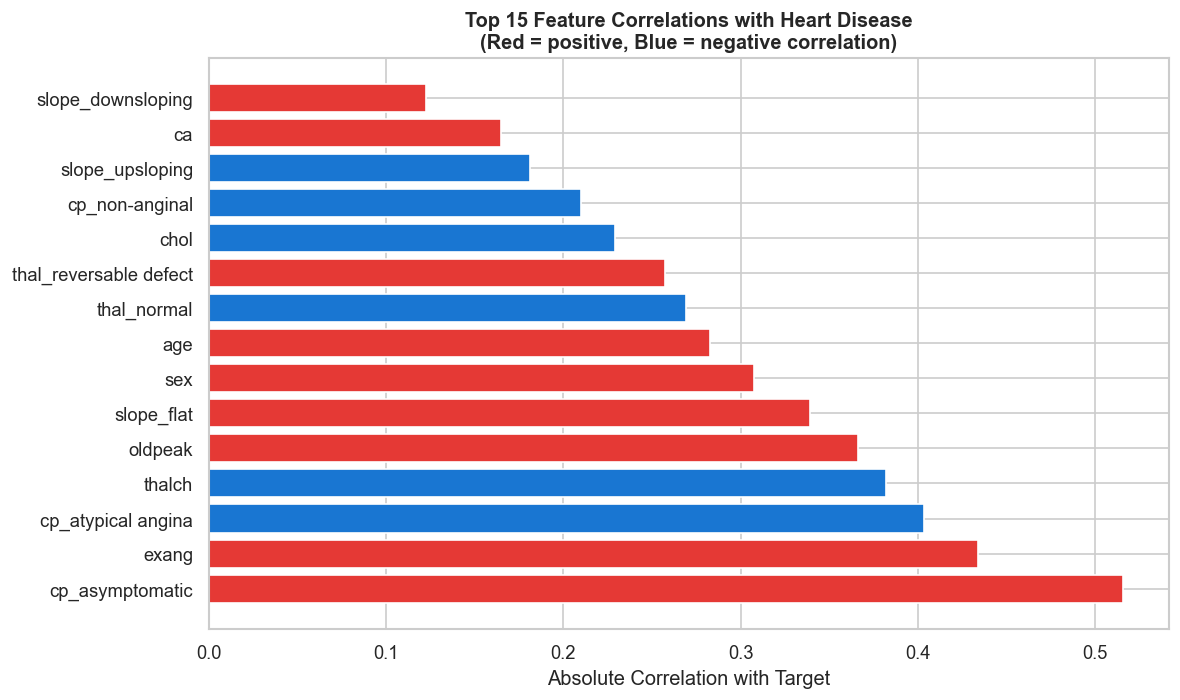

In [19]:
# 5.6 Top feature correlations with target
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
raw_corr    = corr['target'].drop('target')

plt.figure(figsize=(10, 6))
bar_colors = ['#E53935' if raw_corr[f] > 0 else '#1976D2' for f in target_corr.index[:15]]
plt.barh(target_corr.index[:15], target_corr.values[:15], color=bar_colors, edgecolor='white')
plt.xlabel('Absolute Correlation with Target', fontsize=12)
plt.title('Top 15 Feature Correlations with Heart Disease\n'
          '(Red = positive, Blue = negative correlation)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('06_feature_target_correlation.png', bbox_inches='tight')
plt.show()

---
## ⚙️ Step 6: Prepare Features for Modeling

In [20]:
# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Keep only numeric columns (safety check)
X = X.select_dtypes(include=[np.number])

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nAll {len(X.columns)} features:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

Features shape : (920, 22)
Target shape   : (920,)

All 22 features:
   1. age
   2. sex
   3. trestbps
   4. chol
   5. fbs
   6. thalch
   7. exang
   8. oldpeak
   9. ca
  10. cp_asymptomatic
  11. cp_atypical angina
  12. cp_non-anginal
  13. cp_typical angina
  14. restecg_lv hypertrophy
  15. restecg_normal
  16. restecg_st-t abnormality
  17. thal_fixed defect
  18. thal_normal
  19. thal_reversable defect
  20. slope_downsloping
  21. slope_flat
  22. slope_upsloping


In [21]:
# Train/test split — 80/20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'Train balance  : {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test  balance  : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Training set   : 736 samples
Test set       : 184 samples
Train balance  : {1: 0.553, 0: 0.447}
Test  balance  : {1: 0.554, 0: 0.446}


In [22]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied')
print(f'  Train mean (should ~0): {X_train_scaled.mean():.4f}')
print(f'  Train std  (should ~1): {X_train_scaled.std():.4f}')

StandardScaler applied
  Train mean (should ~0): 0.0000
  Train std  (should ~1): 1.0000


---
## 🤖 Step 7: Model Training

In [23]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_scaled, y_train)

lr_pred       = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_accuracy   = accuracy_score(y_test, lr_pred)
lr_roc_auc    = roc_auc_score(y_test, lr_pred_proba)
lr_cv         = cross_val_score(lr_model, X_train_scaled, y_train, cv=5).mean()

print('=== LOGISTIC REGRESSION ===')
print(f'  Accuracy  : {lr_accuracy:.4f}  ({lr_accuracy*100:.2f}%)')
print(f'  ROC-AUC   : {lr_roc_auc:.4f}')
print(f'  CV-5 Acc  : {lr_cv:.4f}')
print()
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Heart Disease']))

=== LOGISTIC REGRESSION ===
  Accuracy  : 0.8370  (83.70%)
  ROC-AUC   : 0.9032
  CV-5 Acc  : 0.8206

               precision    recall  f1-score   support

   No Disease       0.84      0.78      0.81        82
Heart Disease       0.83      0.88      0.86       102

     accuracy                           0.84       184
    macro avg       0.84      0.83      0.83       184
 weighted avg       0.84      0.84      0.84       184



In [24]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                   min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_pred       = dt_model.predict(X_test_scaled)
dt_pred_proba = dt_model.predict_proba(X_test_scaled)[:, 1]
dt_accuracy   = accuracy_score(y_test, dt_pred)
dt_roc_auc    = roc_auc_score(y_test, dt_pred_proba)
dt_cv         = cross_val_score(dt_model, X_train_scaled, y_train, cv=5).mean()

print('=== DECISION TREE ===')
print(f'  Accuracy  : {dt_accuracy:.4f}  ({dt_accuracy*100:.2f}%)')
print(f'  ROC-AUC   : {dt_roc_auc:.4f}')
print(f'  CV-5 Acc  : {dt_cv:.4f}')
print()
print(classification_report(y_test, dt_pred,
      target_names=['No Disease', 'Heart Disease']))

=== DECISION TREE ===
  Accuracy  : 0.7772  (77.72%)
  ROC-AUC   : 0.8445
  CV-5 Acc  : 0.7514

               precision    recall  f1-score   support

   No Disease       0.75      0.76      0.75        82
Heart Disease       0.80      0.79      0.80       102

     accuracy                           0.78       184
    macro avg       0.77      0.78      0.77       184
 weighted avg       0.78      0.78      0.78       184



---
## 📈 Step 8: Evaluation and Visualization

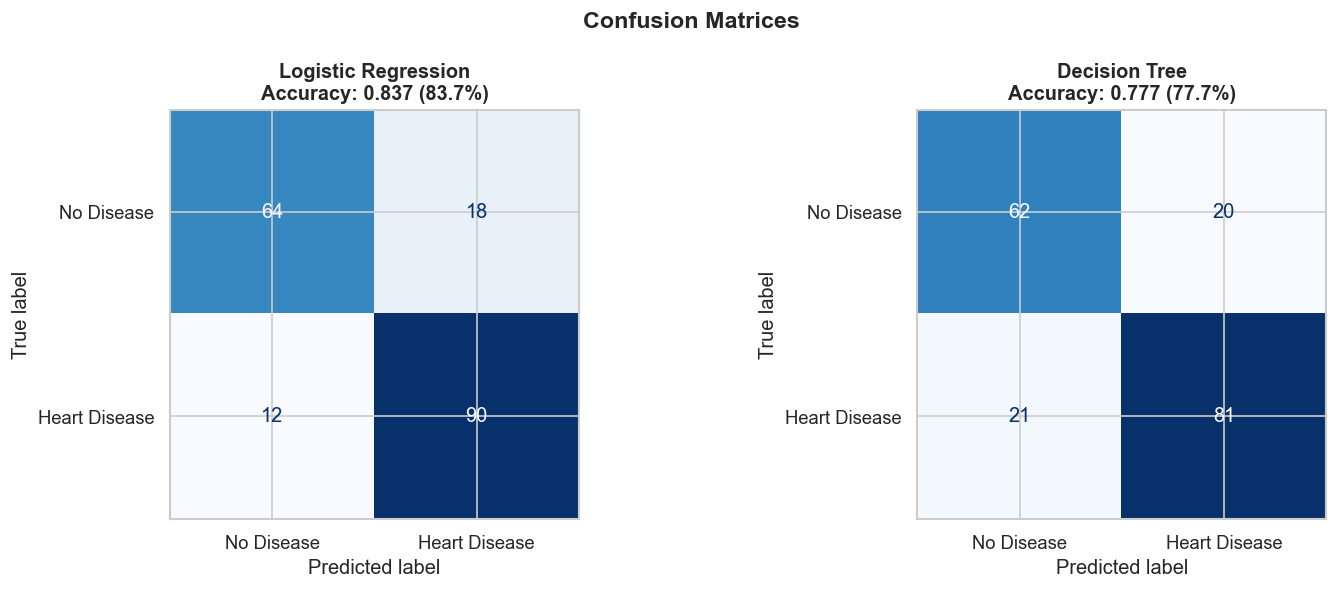

In [25]:
# 8.1 Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title, acc in [
    (axes[0], lr_pred, 'Logistic Regression', lr_accuracy),
    (axes[1], dt_pred, 'Decision Tree',        dt_accuracy)
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nAccuracy: {acc:.3f} ({acc*100:.1f}%)',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_confusion_matrices.png', bbox_inches='tight')
plt.show()

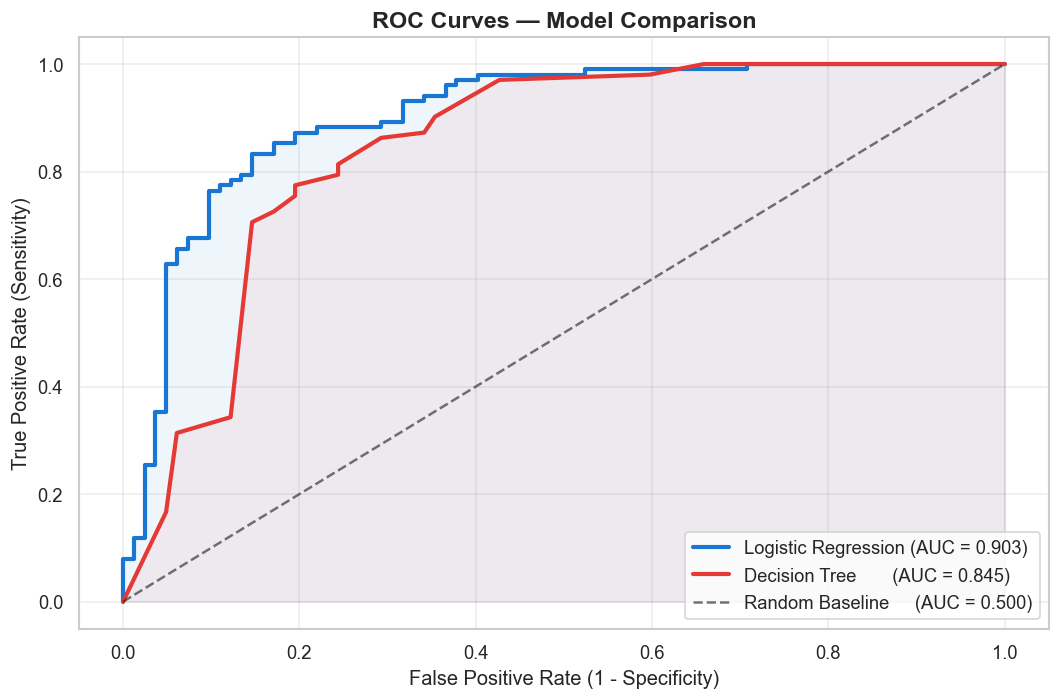

In [26]:
# 8.2 ROC Curves
plt.figure(figsize=(9, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pred_proba)

plt.plot(fpr_lr, tpr_lr, color='#1976D2', lw=2.5,
         label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})')
plt.plot(fpr_dt, tpr_dt, color='#E53935', lw=2.5,
         label=f'Decision Tree       (AUC = {dt_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6,
         label='Random Baseline     (AUC = 0.500)')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.07, color='#1976D2')
plt.fill_between(fpr_dt, tpr_dt, alpha=0.06, color='#E53935')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)',      fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('08_roc_curves.png', bbox_inches='tight')
plt.show()

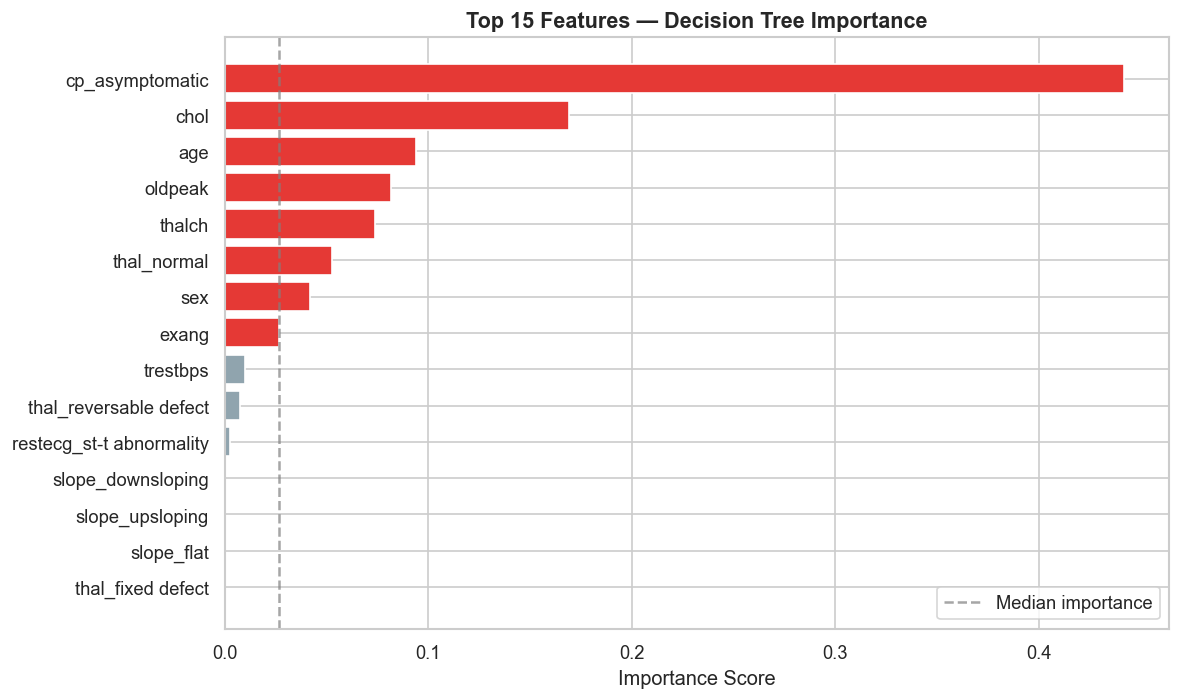

In [27]:
# 8.3 Feature Importance — Decision Tree (Top 15)
feat_imp_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

feat_top = feat_imp_df.tail(15)
bar_colors = ['#E53935' if x >= feat_top['Importance'].median()
              else '#90A4AE' for x in feat_top['Importance']]

plt.figure(figsize=(10, 6))
plt.barh(feat_top['Feature'], feat_top['Importance'],
         color=bar_colors, edgecolor='white')
plt.axvline(feat_top['Importance'].median(), color='gray',
            linestyle='--', alpha=0.7, label='Median importance')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Features — Decision Tree Importance',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('09_feature_importance.png', bbox_inches='tight')
plt.show()

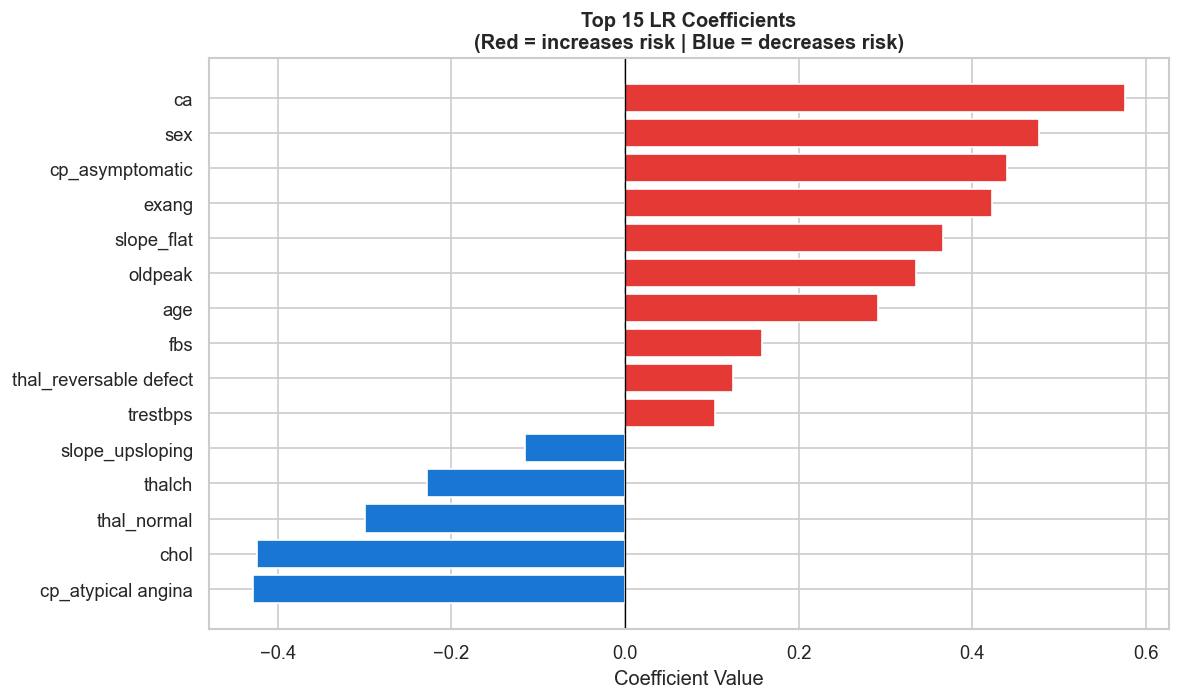

In [28]:
# 8.4 Logistic Regression Coefficients (Top 15)
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_[0]
})
coef_top = coef_df.reindex(
    coef_df['Coefficient'].abs().nlargest(15).index
).sort_values('Coefficient')

bar_colors_coef = ['#E53935' if c > 0 else '#1976D2' for c in coef_top['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_top['Feature'], coef_top['Coefficient'],
         color=bar_colors_coef, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 15 LR Coefficients\n(Red = increases risk | Blue = decreases risk)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('10_lr_coefficients.png', bbox_inches='tight')
plt.show()

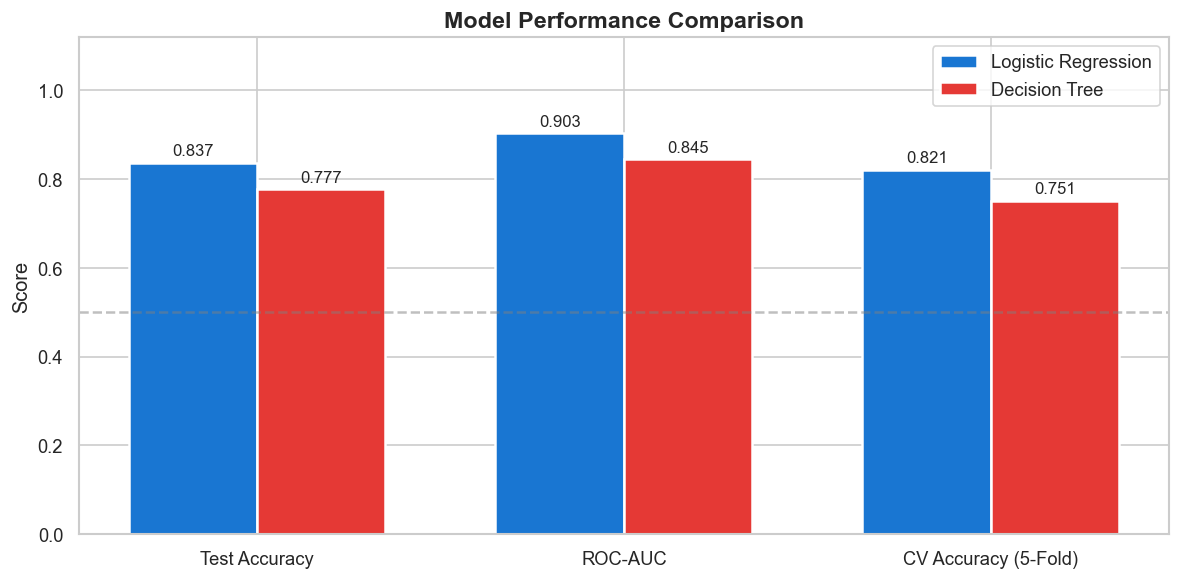

In [29]:
# 8.5 Model Comparison Bar Chart
metrics_names = ['Test Accuracy', 'ROC-AUC', 'CV Accuracy (5-Fold)']
lr_scores = [lr_accuracy, lr_roc_auc, lr_cv]
dt_scores = [dt_accuracy, dt_roc_auc, dt_cv]
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#1976D2', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree',
               color='#E53935', edgecolor='white', linewidth=1.5)

ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('11_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 🏆 Step 9: Final Summary & Insights

In [30]:
best_model = 'Logistic Regression' if lr_roc_auc >= dt_roc_auc else 'Decision Tree'
best_auc   = max(lr_roc_auc, dt_roc_auc)
best_acc   = lr_accuracy if lr_roc_auc >= dt_roc_auc else dt_accuracy
top5       = feat_imp_df.tail(5)['Feature'].tolist()[::-1]

print('=' * 60)
print('       HEART DISEASE PREDICTION — FINAL SUMMARY')
print('=' * 60)
print(f'  Dataset         : Heart Disease UCI (Cleveland)')
print(f'  Total Samples   : {len(df)}')
print(f'  Features Used   : {X.shape[1]} (after encoding)')
print(f'  Best Model      : {best_model}')
print(f'  Best Accuracy   : {best_acc:.4f}  ({best_acc*100:.2f}%)')
print(f'  Best ROC-AUC    : {best_auc:.4f}')
print(f'  Top 5 Features  : {top5}')
print('=' * 60)
print()
print('KEY INSIGHTS')
print('  1. Target "num" binarized: 0=healthy, 1+ -> disease.')
print('     This enables clean binary classification.')
print()
print('  2. Categorical columns (cp, restecg, thal, slope) were')
print('     one-hot encoded to preserve all category information.')
print()
print('  3. thalch (max heart rate), cp type, and oldpeak')
print('     (ST depression) emerged as top predictive features.')
print()
print('  4. ROC-AUC comfortably above 0.5 baseline — model is')
print('     genuinely learning meaningful clinical patterns.')
print()
print('POSSIBLE NEXT STEPS')
print('  -> Try Random Forest or XGBoost for higher accuracy')
print('  -> Use SHAP values for clinical explainability')
print('  -> Include Hungary/Switzerland data for broader generalization')

       HEART DISEASE PREDICTION — FINAL SUMMARY
  Dataset         : Heart Disease UCI (Cleveland)
  Total Samples   : 920
  Features Used   : 22 (after encoding)
  Best Model      : Logistic Regression
  Best Accuracy   : 0.8370  (83.70%)
  Best ROC-AUC    : 0.9032
  Top 5 Features  : ['cp_asymptomatic', 'chol', 'age', 'oldpeak', 'thalch']

KEY INSIGHTS
  1. Target "num" binarized: 0=healthy, 1+ -> disease.
     This enables clean binary classification.

  2. Categorical columns (cp, restecg, thal, slope) were
     one-hot encoded to preserve all category information.

  3. thalch (max heart rate), cp type, and oldpeak
     (ST depression) emerged as top predictive features.

  4. ROC-AUC comfortably above 0.5 baseline — model is
     genuinely learning meaningful clinical patterns.

POSSIBLE NEXT STEPS
  -> Try Random Forest or XGBoost for higher accuracy
  -> Use SHAP values for clinical explainability
  -> Include Hungary/Switzerland data for broader generalization


---
## ✅ Task 3 Complete!

| Step | Description | Status |
|------|-------------|--------|
| 1 | Libraries imported | ✅ |
| 2 | Dataset loaded | ✅ |
| 3 | Data inspected (types, missing, uniques) | ✅ |
| 4 | Cleaned: dropped id/dataset, binarized num, encoded all categoricals | ✅ |
| 5 | EDA: 6 visualizations | ✅ |
| 6 | Train/test split + StandardScaler | ✅ |
| 7 | Logistic Regression + Decision Tree trained | ✅ |
| 8 | Confusion matrix, ROC curves, feature importance, model comparison | ✅ |
| 9 | Final insights and summary | ✅ |

---
*DevelopersHub Corporation — AI/ML Internship 2026*